<img src="./logo_UTN.svg" align="right" width="150" /> 

### Teoría de Circuitos II

# Trabajo Semanal N°1

Autor: *Olea Gasalla Ignacio Ezequiel*

*Fecha de entrega: jueves 30 de mayo de 2026*

#### **Consigna** 
1. Analizar la impedancia de entrada desde el nodo Vx. Hallar los valores de R4,R5,Y1,Y2 e Y3 de tal manera que responda como un Inductor de valor unitario. 

2. Obtener la función transferencia $\frac{V2}{V1}$. Desnormalice convenientemente en frecuencia e impedancia para garantizar una $f_0=10kHz$ y $Q=20$ utilizando Capacitores entre 1 nF y 100 nF. Para los resistores no hay restricciones. 

3.  Simule la transferencia desnormalizada en Python. Se sugiere programar la transferencia normalizada y definir las normas de frecuencia e impedancia para desnormalizar. Verificar los requerimientos pedidos en 2)

In [178]:
from IPython.display import IFrame
IFrame("./tc2_ts1_oft.pdf", width=1000, height=1000)


In [2]:
# Importo las librerias
import sympy as sp
from sympy import Eq
from IPython.display import display

# Declaro qué es variable, componente y tensiones.
s = sp.symbols('s')
R, C, R1, C2, R3, R4, R5 = sp.symbols('R C R1 C2 R3 R4 R5')
V1, V2, Va = sp.symbols('V1 V2 Va')  # Vx = V+ = V-

# Agrego las ecuaciones de nodos
eq1 = V2*(R5/(R4+R5))*s*C + (V2*(R5/(R4+R5))-Va)/R1 - (V1-V2*(R5/(R4+R5)))/R
eq2 = (Va-V2*(R5/(R4+R5)))*s*C2 - (V2*(R5/(R4+R5))-V2)/R3
sol = sp.solve([eq1, eq2], (Va, V2))

# Armo la transferencia y la presento
H = sp.simplify(sol[V2] / V1)
display(Eq(sp.Function('T')(s), H))


Eq(T(s), C2*R1*R3*s*(R4 + R5)/(C*C2*R*R1*R3*R5*s**2 + C2*R1*R3*R5*s + R*R4))

En el siguiente código se normalizó la transferencia y permite pasarle las variables: $f_0$, $Q$, $C$ y $|T(jw_0)|$ siendo $|T(jw_0)|$ el módulo de la transferencia evaluado en $w_0$, de esta forma controlamos la frecuencia a la que desnormalizamos, el Q que deseamos tener, el valor real del capacitor que podemos usar y cuanta ganancia queremos tener en $s=jw0$ (en dB), en el ejemplo elegí que sea +20 dB. Este código devuelve el gráfico de la tranferencia normalizada y el gráfico de la tranferencia sin normalizar (a la frecuencia deseada) junto con los valores de componentes que se deben utilizar para llegar a esa frecuencia.

NOTA: Se decidió priorizar la elección del valor del capacitor (C) antes que el valor del nivel de impedancia (Z) para facilitar el uso del programa a los usuarios.

Los valores a usar para f0 = 10.0 kHz , Q = 20.0 , C = 4.7 nF y |T(jw0)| = 20.0 dB son:
   R = 67.7 kΩ 
   C = 4.7 nF
   L = 53.9 mH
   R4/R5 = 9.0 


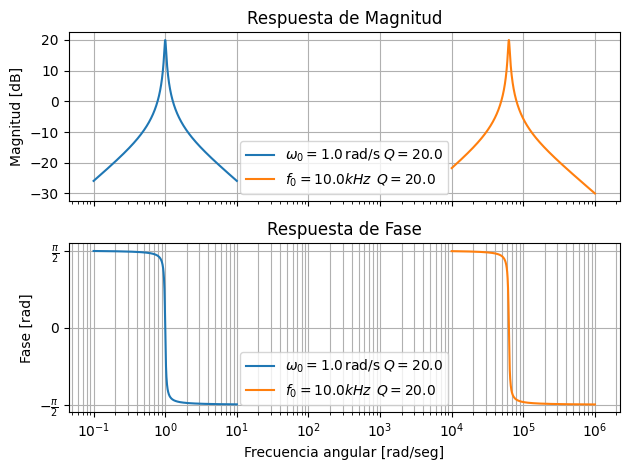

In [174]:
# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
import matplotlib.pyplot as plt
import numpy as np
import math

# Librería de TC2, esta la vas a usar mucho
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

# Función para mostrar en formato de ingenieria las unidades
def eng_format(value, unit=""):
    import numpy as np
    
    if value == 0:
        return f"0 {unit}"
    
    exp = int(np.floor(np.log10(abs(value)) / 3) * 3)
    scaled = value / (10**exp)
    
    prefixes = {
        -12: "p",
        -9: "n",
        -6: "u",
        -3: "m",
         0: "",
         3: "k",
         6: "M",
         9: "G"
    }
    
    prefix = prefixes.get(exp, f"e{exp}")
    
    return f"{scaled:.1f} {prefix}{unit}"

#--------------------------------------------------------------------------

# Valores de f0, Q y C queridos:
f0  = 10 * 10**3        # f0       = 10kHz
Q   = 20                # Q        = 20
C   = 4.7 * 10**(-9)    # C        = 4.7nF
Tw0 = 20                # |T(jw0)| = +20dB

w0  = f0 * 2*np.pi    
rel = 10 ** (Tw0/20) -1 #rel = R4/R5

# Valores normalizados (w0 = 1 r/s) y con la Q elegida (Q=20)
Cn = 1
Ln = 1 / Cn
Rn = Q / Cn

Q_  = Rn * np.sqrt( Cn / Ln ) 
w0_ = 1 / np.sqrt( Cn * Ln )
f0_ = w0_ / (2 * np.pi)

my_tf = TransferFunction( [ (1+rel)*(w0_/Q_) , 0 ], [1, w0_/Q_ , (w0_)**2] )
bodePlot(my_tf, fig_id=1, filter_description = rf"$\omega_0 = {w0_:.1f}\,\mathrm{{rad/s}}\; Q = {Q_:.1f}$" )

# Valores desnormalizados (w0 = 2πf0) y con la Q elegida (Q=20)
Z = Cn / ( C * w0 )
L = Ln * Z / w0
R = Rn * Z

Q_  = R * np.sqrt( C / L ) 
w0_ = 1 / np.sqrt( C * L )
f0_ = w0_ / (2 * np.pi)

my_tf = TransferFunction( [ (1+rel)*(w0_/Q_) , 0 ], [1, w0_/Q_ , (w0_)**2] )
bodePlot(my_tf, fig_id=1, filter_description = rf"$ f_0 = {eng_format(f0_, "Hz")}\,\; Q = {Q_:.1f}$")

print(rf"Los valores a usar para f0 = {eng_format(f0, "Hz")} , Q = {Q:.1f} , C = {eng_format(C, 'F')} y |T(jw0)| = {Tw0:.1f} dB son:")
print(rf"   R = {eng_format(R, 'Ω')} ")
print(rf"   C = {eng_format(C, 'F')}")
print(rf"   L = {eng_format(L, 'H')}")
print(rf"   R4/R5 = {rel:.1f} ")

plt.figure(1)
plt.tight_layout()
plt.autoscale()
plt.grid(True, which="minor")

Bonus:
1. El código de arriba permite elegir que el pasa banda tenga una ganancia en decibeles concreta y que con ello, te retorna el valor de la relación $\frac{R4}{R5}$. En el caso de $+20dB$, valor de $R4=9R5$. Algunos valores de ejemplo serian $R5=120\Omega$ y $R5=1080\Omega$; si se usa una $R5=1000\Omega$ la relación $\frac{R4}{R5} = 8.3$ lo que da una ganancia en $f_0$ de $+19.4dB$.
2. EL principal inconveniente es la referencia a la masa, para poder usarlo en la segunda figura se deberia adaptar el circuito y no se podría usar de forma directa.
3.  $BW=f_2-f_1=9.7224kHz \mid f_1=469.6Hz \land f_1=10.192KHz $ y se comprueba en el gráfico que, con el eje logaritmico, $f_o$ está centrado entre $f_1$ y 

<img src="./tc2_ts1_LTSpice.png"/> 